# 1. Loading and Preprocessing

In [71]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from matplotlib.colors import LinearSegmentedColormap



### 1.1 Data Loading

In [72]:
folderpath = kagglehub.dataset_download("thedevastator/airlines-traffic-passenger-statistics")

filepath = folderpath + '/' + 'Air_Traffic_Passenger_Statistics.csv'

df = pd.read_csv(filepath)

In [73]:
df.head()

,index,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July


### 1.2 Data Preprocessing

In [74]:
df['Year'] = df['Activity Period'].astype(str).str[0:4]
df['Month'] = df['Activity Period'].astype(str).str[4:]

df['Period'] =  df['Month'] + '-01' + '-' +  df['Year']
df['Period'] = pd.to_datetime(df['Period'])
df['YearDay'] = df['Period'].dt.dayofyear

flights = pd.DataFrame(df.groupby('Period')['Passenger Count'].sum())

# 2. Exploratory Data Analysis

### 2.1 Plot the time series


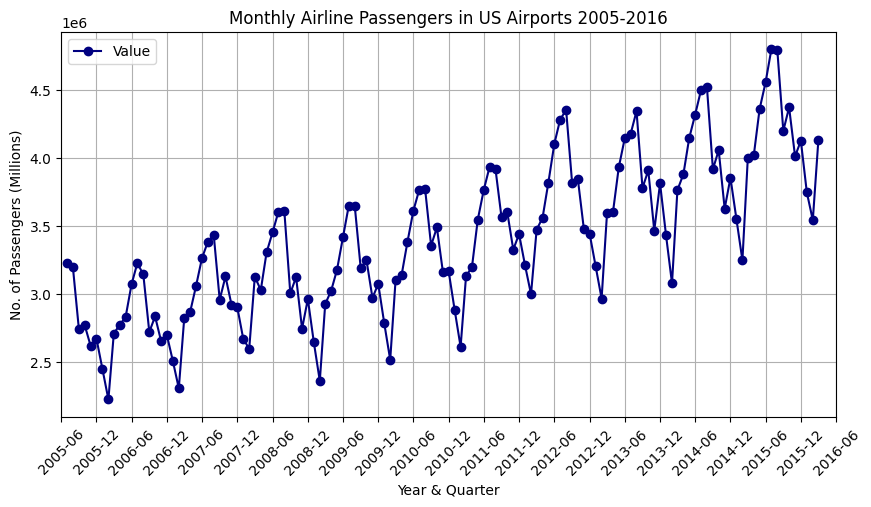

In [75]:
plt.figure(figsize=(10, 5))
plt.plot(flights.index, flights['Passenger Count'], marker="o", linestyle="-", color="#000080", label="Value")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

new_xlim = [flights.index.min() + pd.DateOffset(months=-1), flights.index.max() + pd.DateOffset(months=3)]
ax.set_xlim(new_xlim)

plt.xlabel("Year & Quarter")
plt.ylabel("No. of Passengers (Millions)")
plt.title("Monthly Airline Passengers in US Airports 2005-2016")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.show()

### 2.2 Check for seasonality and periodicity


#### 2.2.1 Decomposition

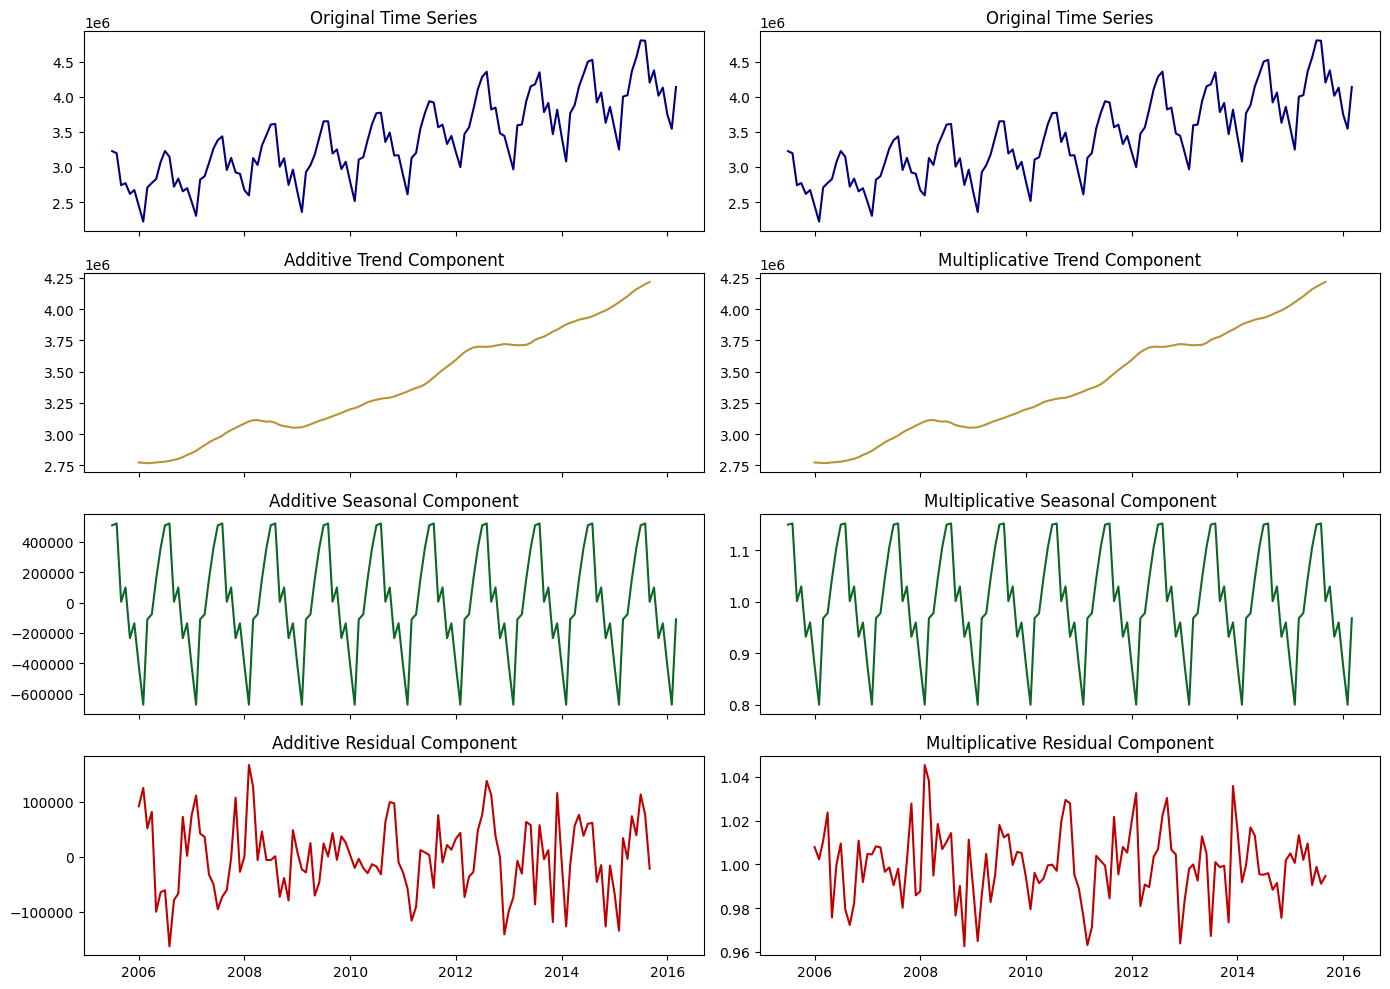

In [76]:
# ---  Apply Additive and Multiplicative Decomposition ---
additive_decomposition = seasonal_decompose(flights["Passenger Count"], model="additive", period=12)
multiplicative_decomposition = seasonal_decompose(flights["Passenger Count"], model="multiplicative", period=12)

# Plot both decompositions side by side
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)

navy = "#000080"
gold = "#B89336"
green = "#0B6725"
red = "#C00000"

# Additive Decomposition Plots
axes[0, 0].plot(flights.index, flights["Passenger Count"], color="#000080")
axes[0, 0].set_title("Original Time Series")

axes[1, 0].plot(flights.index, additive_decomposition.trend, color="#B89336")
axes[1, 0].set_title("Additive Trend Component")

axes[2, 0].plot(flights.index, additive_decomposition.seasonal, color="#0B6725")
axes[2, 0].set_title("Additive Seasonal Component")

axes[3, 0].plot(flights.index, additive_decomposition.resid, color="#C00000")
axes[3, 0].set_title("Additive Residual Component")

# Multiplicative Decomposition Plots
axes[0, 1].plot(flights.index, flights["Passenger Count"], color="#000080")
axes[0, 1].set_title("Original Time Series")

axes[1, 1].plot(flights.index, multiplicative_decomposition.trend, color="#B89336")
axes[1, 1].set_title("Multiplicative Trend Component")

axes[2, 1].plot(flights.index, multiplicative_decomposition.seasonal, color="#0B6725")
axes[2, 1].set_title("Multiplicative Seasonal Component")

axes[3, 1].plot(flights.index, multiplicative_decomposition.resid, color="#C00000")
axes[3, 1].set_title("Multiplicative Residual Component")

plt.tight_layout()
plt.show()

#### 2.2.2 Validation

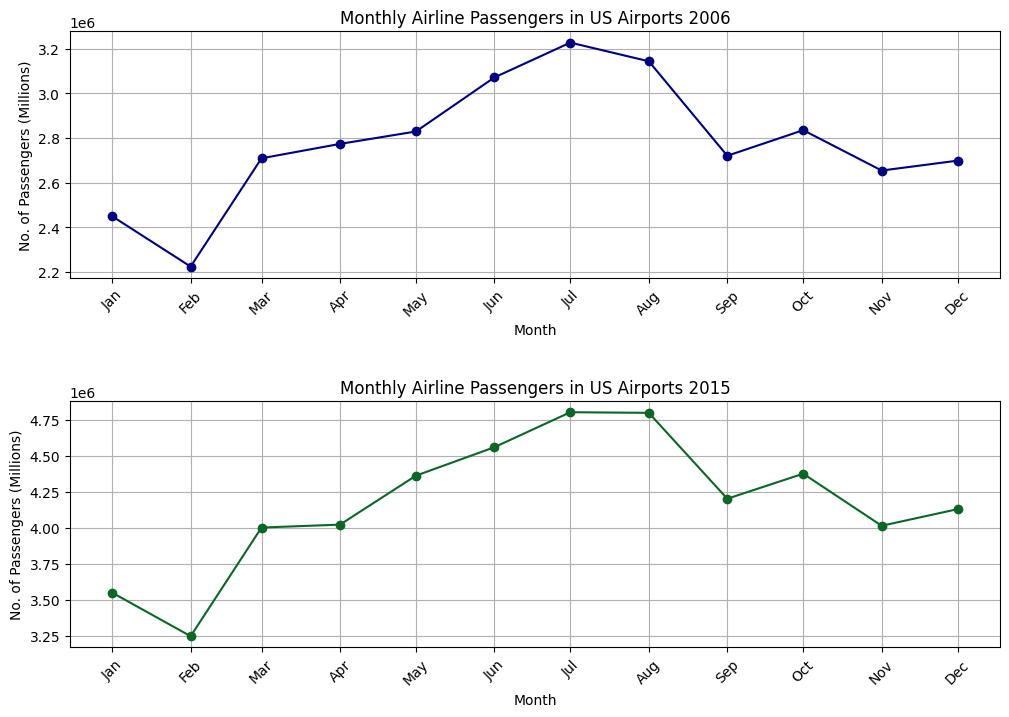

In [77]:
year2006 = ('2006-01-01' <= flights.index) & (flights.index <='2006-12-31')
year2015 = ('2015-01-01' <= flights.index) & (flights.index <='2015-12-31')
df2006 = flights[year2006]
df2015 = flights[year2015]

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=False)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
    ax.tick_params(axis='x', rotation=45)

axes[0].plot(df2006.index, df2006['Passenger Count'], marker="o", linestyle="-", color=navy, label="Value")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("No. of Passengers (Millions)")
axes[0].set_title("Monthly Airline Passengers in US Airports 2006")
axes[0].grid()

axes[1].plot(df2015.index, df2015['Passenger Count'], marker="o", linestyle="-", color=green, label="Value")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("No. of Passengers (Millions)")
axes[1].set_title("Monthly Airline Passengers in US Airports 2015")
axes[1].grid()

plt.subplots_adjust(hspace=0.5)

In [78]:
## Larger magnitude of seasonality in later years, increasing trend indicates should use multiplicative seasonality

### 2.3 Compute summary statistics


In [79]:
flights.describe()

,Passenger Count
count,1.290000e+02
mean,3.401647e+06
std,5.672446e+05
min,2.223024e+06
25%,2.971484e+06
50%,3.380355e+06
75%,3.814984e+06
max,4.801148e+06


### 2.4 Visualise autocorrelation (ACF, PACF)


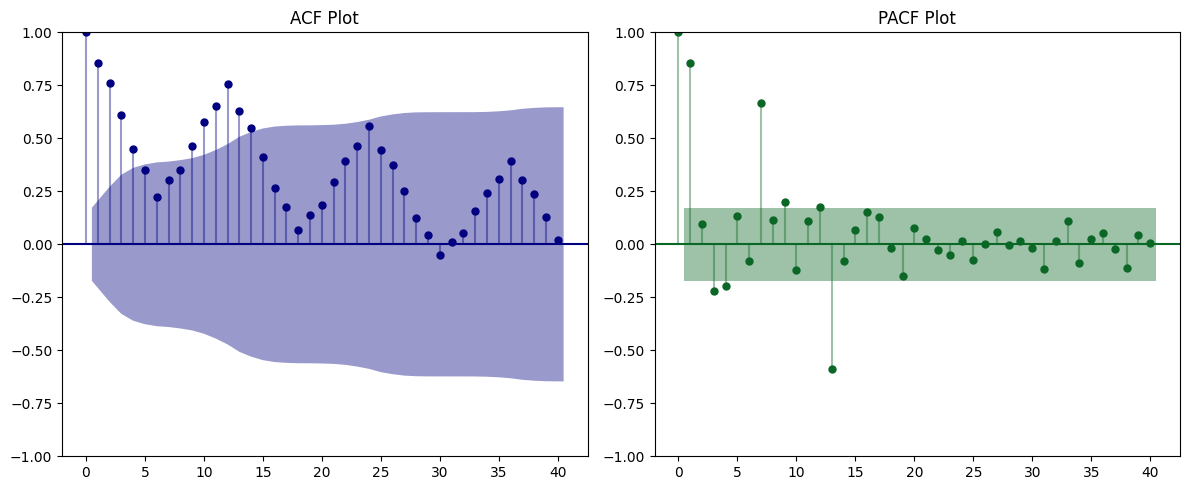

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_acf(flights["Passenger Count"].dropna(), lags=40, ax=axes[0], color=navy,vlines_kwargs={'colors': navy})
for patch in axes[0].collections:
    patch.set_facecolor(navy)  # Change CI fill color
    patch.set_alpha(0.4)
plot_pacf(flights["Passenger Count"].dropna(), lags=40, ax=axes[1],color=green,vlines_kwargs={'colors': green})
for patch in axes[1].collections:
    patch.set_facecolor(green)  # Change CI fill color
    patch.set_alpha(0.4)
axes[0].set_title("ACF Plot")
axes[1].set_title("PACF Plot")
plt.tight_layout()
plt.show()

# 3. Transformations

### 3.2 Differencing

#### 3.2.1 Apply and Test Differencing

In [81]:
# Perform Augmented Dickey-Fuller (ADF) test
adf_result_before = adfuller(flights["Passenger Count"].dropna())
print(f"ADF Statistic before differencing: {adf_result_before[0]:.4f}")
print(f"P-value before differencing: {adf_result_before[1]:.4f}\n")


flights["Differenced"] = flights["Passenger Count"].diff().dropna()

# Re-run ADF on differenced series
adf_result_diff = adfuller(flights["Differenced"] .dropna())
print(f"ADF Statistic (Differenced): {adf_result_diff[0]:.4f}")
print(f"P-value (Differenced): {adf_result_diff[1]:.4f}")

ADF Statistic before differencing: 0.2342
P-value before differencing: 0.9741

ADF Statistic (Differenced): -3.2112
P-value (Differenced): 0.0193


In [82]:
residuals = multiplicative_decomposition.resid
trend = multiplicative_decomposition.trend
seasonal = multiplicative_decomposition.seasonal

# Perform Augmented Dickey-Fuller (ADF) test
adf_result_before = adfuller(residuals.dropna())
print(f"ADF Statistic before differencing: {adf_result_before[0]:.4f}")
print(f"P-value before differencing: {adf_result_before[1]:.4f}\n")


residualsDiff = residuals.diff().dropna()

# Re-run ADF on differenced series
adf_result_diff = adfuller(residualsDiff.dropna())
print(f"ADF Statistic (Differenced): {adf_result_diff[0]:.4f}")
print(f"P-value (Differenced): {adf_result_diff[1]:.4f}")

ADF Statistic before differencing: -6.0972
P-value before differencing: 0.0000

ADF Statistic (Differenced): -5.9874
P-value (Differenced): 0.0000


#### 3.2.2 ACF/PACF of Differenced Series

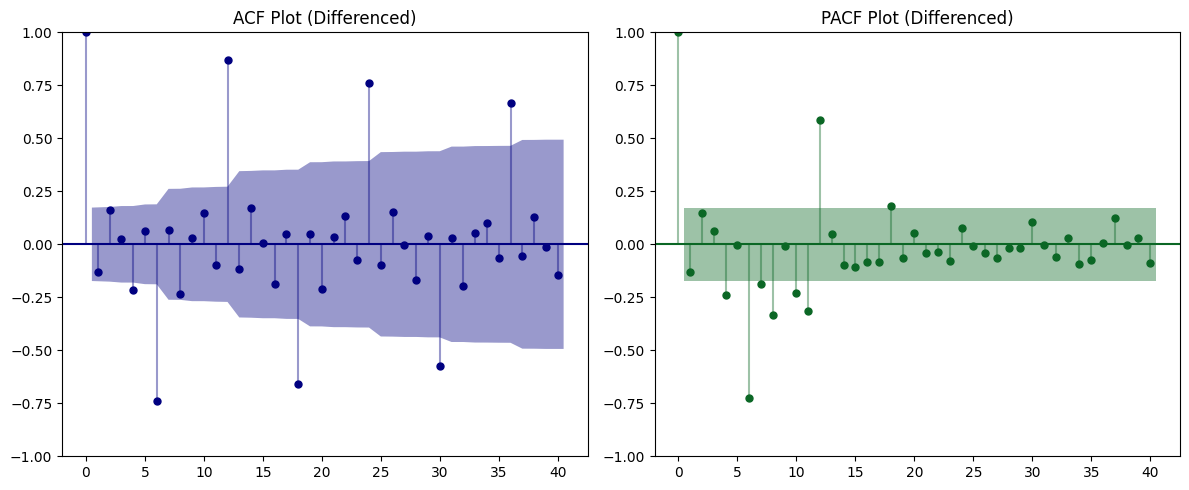

In [83]:


fig, axes = plt.subplots(1, 2, figsize=(12,5))
plot_acf(flights["Differenced"].dropna(), lags=40, ax=axes[0], color=navy,vlines_kwargs={'colors': navy})
for patch in axes[0].collections:
    patch.set_facecolor(navy)  # Change CI fill color
    patch.set_alpha(0.4)
plot_pacf(flights["Differenced"].dropna(), lags=40, ax=axes[1],color=green,vlines_kwargs={'colors': green})
for patch in axes[1].collections:
    patch.set_facecolor(green)  # Change CI fill color
    patch.set_alpha(0.4)
axes[0].set_title("ACF Plot (Differenced)")
axes[1].set_title("PACF Plot (Differenced)")
plt.tight_layout()
plt.show()

# 4. Modelling

### 4.0 ARMA

#### 4.0.1 BIC/AIC Optimisation

In [84]:
# Define range of p, d, q values to test
p = range(0, 10)
d = [0] # Because it's an ARMA model, already stationary  
q = range(0, 10)

# Store results
results_list = []

# Loop through all possible combinations of p, d, q
for param in itertools.product(p, d, q):
    try:
        model = ARIMA(residuals.dropna(), order=param)
        model_fit = model.fit()
        results_list.append([param, model_fit.aic, model_fit.bic])
    except:
        continue  # Skip invalid models

# Convert results to a DataFrame
results_df_ARMA = pd.DataFrame(results_list, columns=["(p,d,q)", "AIC", "BIC"])

# Sort by AIC (or BIC) to find the best model
results_df_ARMA = results_df_ARMA.sort_values(by="AIC")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

#### 4.0.2 Modelling

#### 4.0.2.1 Model Fitting

In [85]:
# Drop NaN values from residual component
residuals = residuals.dropna()

optimal_pdq_ARIMA = results_df_ARMA['(p,d,q)'].iloc[0]
print(optimal_pdq_ARIMA)

# Fit ARIMA model on residuals
model = ARIMA(residuals, order=(3,0,8))
arma_results = model.fit()

(0, 0, 6)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### 4.0.2.2 Residual Plotting

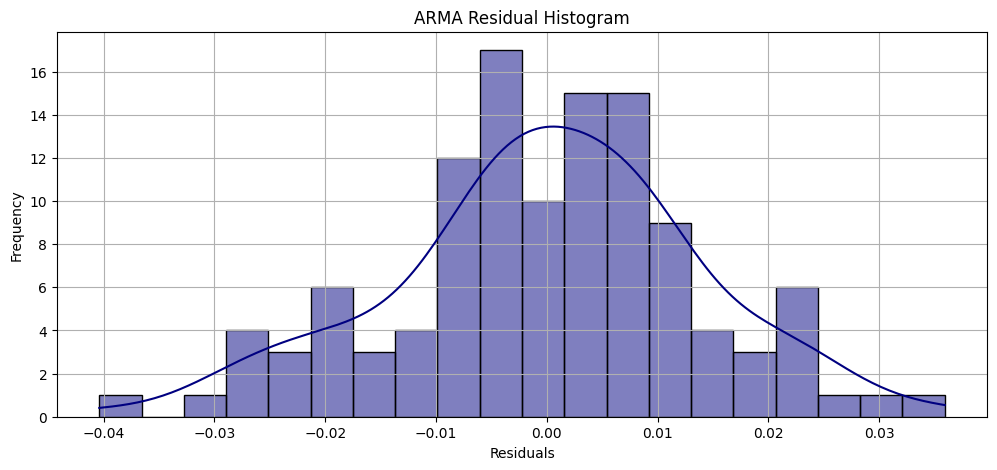

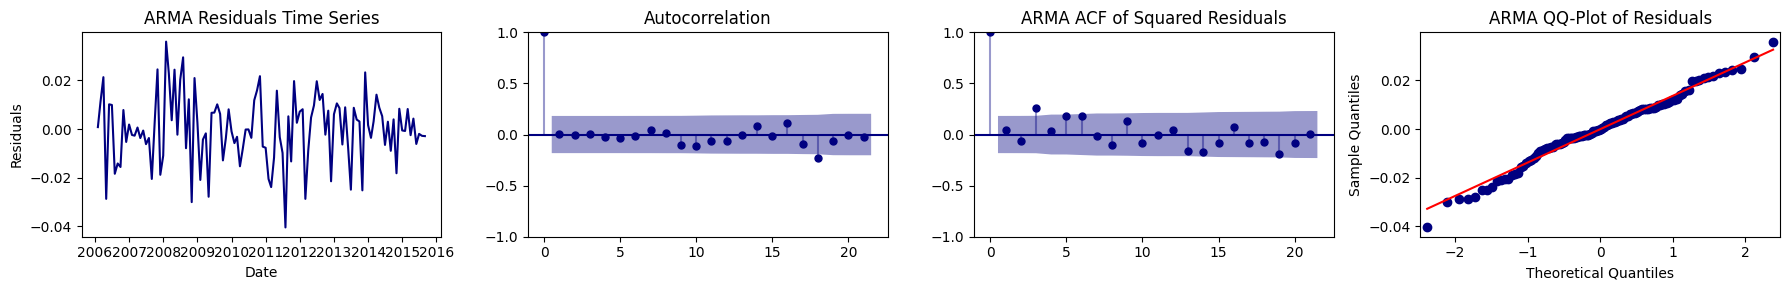

In [86]:
import statsmodels.api as sm

arma_resid = arma_results.resid
arma_resid = arma_resid[1:] # there was an error value in the first column


plt.figure(figsize=(12, 5))
sns.histplot(arma_resid, bins=20, kde=True,color=navy)
plt.title("ARMA Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()

plt.show()

# Create a 1x4 grid of plots
fig, axes = plt.subplots(1, 4, figsize=(18, 3))

# 1. Time series plot of the residuals
axes[0].plot(arma_resid,color=navy)
axes[0].set_title("ARMA Residuals Time Series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residuals")

# 2. ACF plot of the residuals
plot_acf(arma_resid, ax=axes[1],color=navy,vlines_kwargs={'colors': navy})
for patch in axes[1].collections:
    patch.set_facecolor(navy)  # Change CI fill color
    patch.set_alpha(0.4)
axes[2].set_title("ARMA ACF of Residuals")

# 3. ACF plot of the squared residuals
plot_acf(arma_resid**2, ax=axes[2],color=navy,vlines_kwargs={'colors': navy})
for patch in axes[2].collections:
    patch.set_facecolor(navy)  # Change CI fill color
    patch.set_alpha(0.4)
axes[2].set_title("ARMA ACF of Squared Residuals")

# 4. QQ-plot of the residuals
sm.qqplot(arma_resid, line='s', ax=axes[3])
for line in axes[3].get_lines():
    line.set_markerfacecolor('navy')  # Change marker face color
    line.set_markeredgecolor('navy')
axes[3].set_title("ARMA QQ-Plot of Residuals")

plt.tight_layout()
plt.show()

#### 4.0.3 Forecasting

##### 4.0.3.1 In-Sample Forecasting

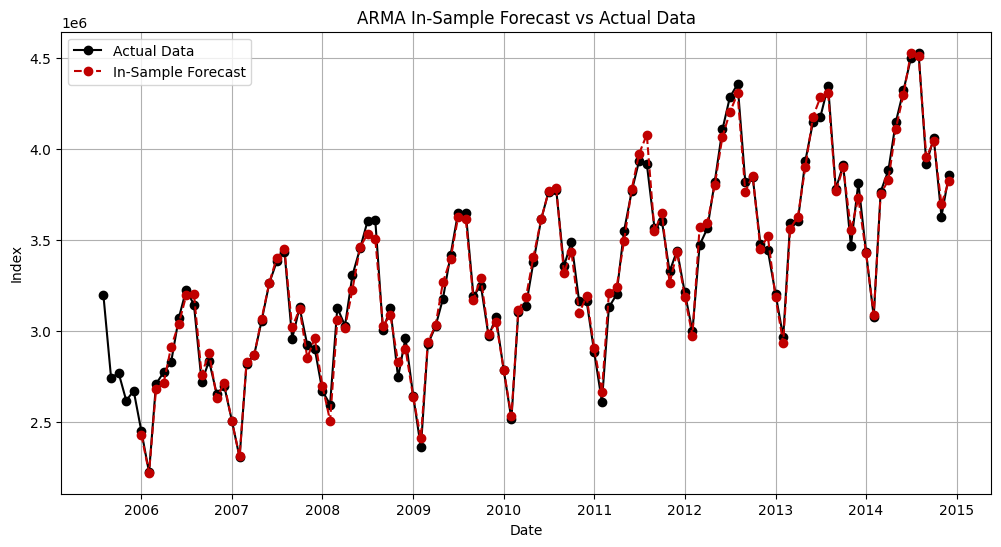

In [109]:
import matplotlib.pyplot as plt

# Split data: use data before 2018 for fitting; for plotting, only 2017 and 2018 are shown.
train0 = flights[flights.index.year < 2015]
test0 = flights[flights.index.year == 2015]
train0_plot = flights[flights.index.year == 2014]

in_sample_forecast0 = arma_results.fittedvalues.reindex(train0.index)
trend_component = trend.dropna()
seasonal_component = seasonal.dropna()
in_sample_forecast0 = in_sample_forecast0.reindex(trend_component.index)
seasonal_component = seasonal_component.reindex(trend_component.index)
final_arma_forecast = in_sample_forecast0 * trend_component * seasonal_component
final_arma_forecast = final_arma_forecast.reindex(train0.index)

# Plot actual vs. in-sample forecast
plt.figure(figsize=(12, 6))
plt.plot(train0.index[1:], train0['Passenger Count'].iloc[1:], label="Actual Data", marker='o', linestyle="-", color="black")
plt.plot(train0.index[1:], final_arma_forecast.iloc[1:], label="In-Sample Forecast", marker='o', linestyle="--", color=red)

plt.xlabel("Date")
plt.ylabel("Index")
plt.title("ARMA In-Sample Forecast vs Actual Data")
plt.legend()
plt.grid()
plt.show()

##### 4.0.3.2 Out-of-Sample Forecasting

In [110]:
# Ensure date index is in datetime format and has monthly frequency
test0.index = pd.to_datetime(test0.index)
train0.index = pd.to_datetime(train0.index)
test1= test0.asfreq('MS')
train0 = train0.asfreq('MS')


# Fit ARIMA model
model = ARIMA(train0['Passenger Count'], order=(0,0,6))
current_results = model.fit()

# Initialize forecast storage
one_step_forecasts0 = pd.Series(index=test0.index, dtype=float)
one_step_ci_lower0 = pd.Series(index=test0.index, dtype=float)
one_step_ci_upper0 = pd.Series(index=test0.index, dtype=float)

# Rolling one-step ahead forecasts
for date in test0.index:
    forecast_obj = current_results.get_forecast(steps=1)
    forecast_value = forecast_obj.predicted_mean.iloc[0]
    ci = forecast_obj.conf_int().iloc[0]

    one_step_forecasts0.loc[date] = forecast_value
    one_step_ci_lower0.loc[date] = ci[0]
    one_step_ci_upper0.loc[date] = ci[1]

    row_to_append = pd.DataFrame({'Passenger Count': [test0.loc[date, 'Passenger Count']]}, 
                                 index=[date])
    current_results = current_results.append(row_to_append, refit=False)

# 12-month forecast from the end of 2017
forecast_res0 = current_results.get_forecast(steps=12)
forecast_mean0 = forecast_res0.predicted_mean
forecast_ci0 = forecast_res0.conf_int()


/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/3618960622.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  one_step_ci_lower0.loc[date] = ci[0]
/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/3618960622.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  one_step_ci_upper0.loc[date] = ci[1]
/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/3618960622.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

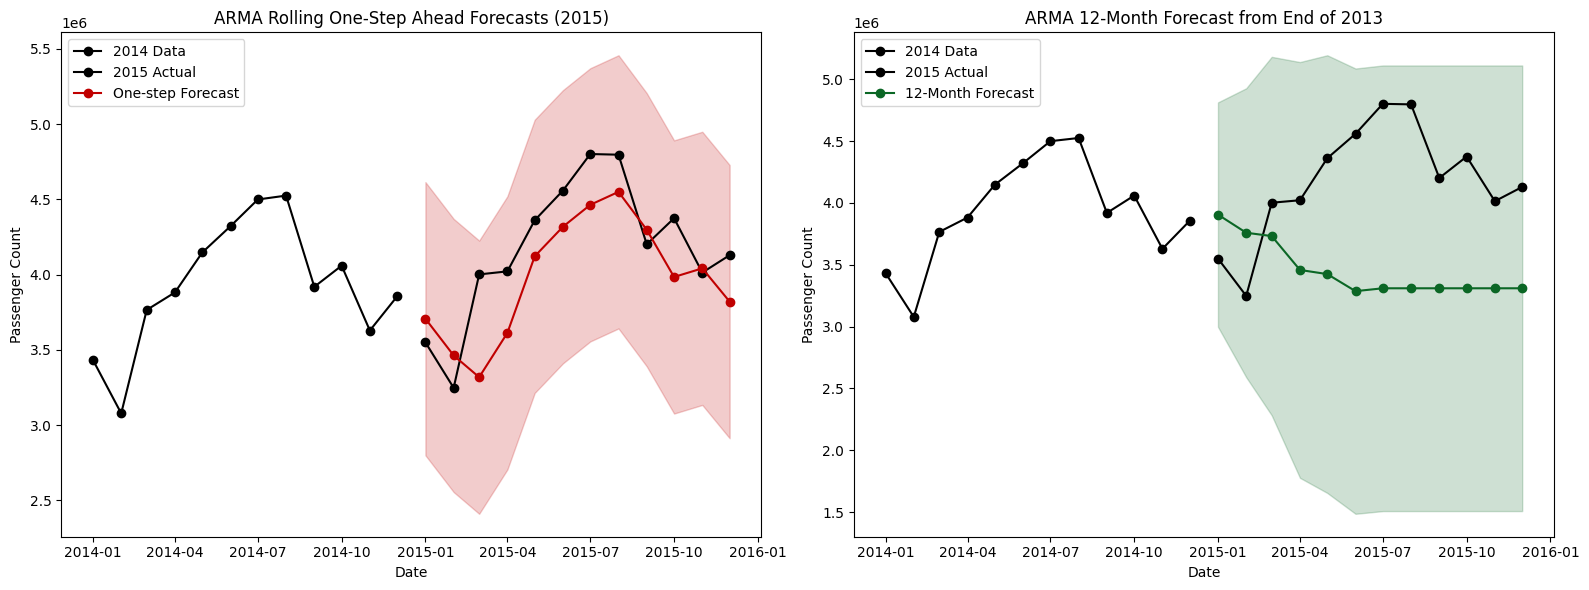

In [111]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Rolling one-step ahead forecasts
axes[0].plot(train0.index[-12:], train0['Passenger Count'].iloc[-12:], label='2014 Data', marker='o', color='black')
axes[0].plot(test0.index, test0['Passenger Count'], label='2015 Actual', color='black', marker='o')
axes[0].plot(one_step_forecasts0.index, one_step_forecasts0, label='One-step Forecast', color=red, marker='o')
axes[0].fill_between(one_step_forecasts0.index, one_step_ci_lower0, one_step_ci_upper0, color=red, alpha=0.2)
axes[0].set_title("ARMA Rolling One-Step Ahead Forecasts (2015)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Passenger Count")
axes[0].legend()

# Correct the forecast index to start at the correct time (January 2014)
forecast_index0 = pd.date_range(start=train0.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Assign the corrected index to forecast values
forecast_mean0.index = forecast_index0
forecast_ci0.index = forecast_index0

# Right plot: 12-month ahead forecast from the end of 2013
axes[1].plot(train0.index[-12:], train0['Passenger Count'].iloc[-12:], label='2014 Data', marker='o',color='black')
axes[1].plot(test0.index, test0['Passenger Count'], label='2015 Actual', color='black', marker='o')

# Ensure forecast_mean and forecast_ci are properly indexed before plotting
axes[1].plot(forecast_mean0.index, forecast_mean0, label='12-Month Forecast', color=green, marker='o')
axes[1].fill_between(forecast_ci0.index, forecast_ci0.iloc[:, 0], forecast_ci0.iloc[:, 1], color=green, alpha=0.2)

axes[1].set_title("ARMA 12-Month Forecast from End of 2013")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Passenger Count")
axes[1].legend()

plt.tight_layout()
plt.show()

##### 4.0.3.3 Forecasting Evaluation

In [112]:
from sklearn.metrics import mean_absolute_error

# Ensure both series have the same index
common_index0_one_step = test0.index.intersection(one_step_forecasts0.index)
common_index0_forecast = test0.index.intersection(forecast_mean0.index)

# Align test data with forecasts
test0_one_step_aligned = test0.loc[common_index0_one_step, 'Passenger Count']
one_step_forecasts_aligned0 = one_step_forecasts0.loc[common_index0_one_step]

test0_forecast_aligned = test0.loc[common_index0_forecast, 'Passenger Count']
forecast_mean_aligned0 = forecast_mean0.loc[common_index0_forecast]

# Compute MAE for both forecasts
mae_one_step0 = mean_absolute_error(test0_one_step_aligned, one_step_forecasts_aligned0)
mae_forecast0 = mean_absolute_error(test0_forecast_aligned, forecast_mean_aligned0)

print(f"ARMA One-Step Ahead Forecast MAE: {mae_one_step0:.2f}")
print(f"ARMA 12-Month Forecast MAE: {mae_forecast0:.2f}")

ARMA One-Step Ahead Forecast MAE: 279232.98
ARMA 12-Month Forecast MAE: 863771.53


### 4.1 ARIMA

#### 4.1.1 AIC/BIC Optimisation

In [113]:
import itertools
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Define range of p, d, q values to test
p = range(0, 10)
d = [1]  
q = range(0, 10)

# Store results
results_list = []

flights.index = pd.date_range(start=flights.index[0], periods=len(flights), freq='MS')  # Adjust frequency as needed

# Loop through all possible combinations of p, d, q
for param in itertools.product(p, d, q):
    try:
        model = ARIMA(flights["Passenger Count"].dropna(), order=param)
        model_fit = model.fit()
        results_list.append([param, model_fit.aic, model_fit.bic])
    except:
        continue  # Skip invalid models


results_df_ARIMA = pd.DataFrame(results_list, columns=["(p,d,q)", "AIC", "BIC"])

# Sort by AIC (or BIC) to find the best model
results_df_ARIMA = results_df_ARIMA.sort_values(by="AIC")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conver

#### 4.1.2 Modelling

##### 4.1.2.1 Model Fitting

In [114]:
optimal_pdq_ARIMA = results_df_ARIMA['(p,d,q)'].iloc[0]
print(optimal_pdq_ARIMA)

model = ARIMA(flights["Passenger Count"].dropna(), order=optimal_pdq_ARIMA)
arima_results = model.fit()

(6, 1, 6)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


##### 4.1.2.2 Residual Plotting

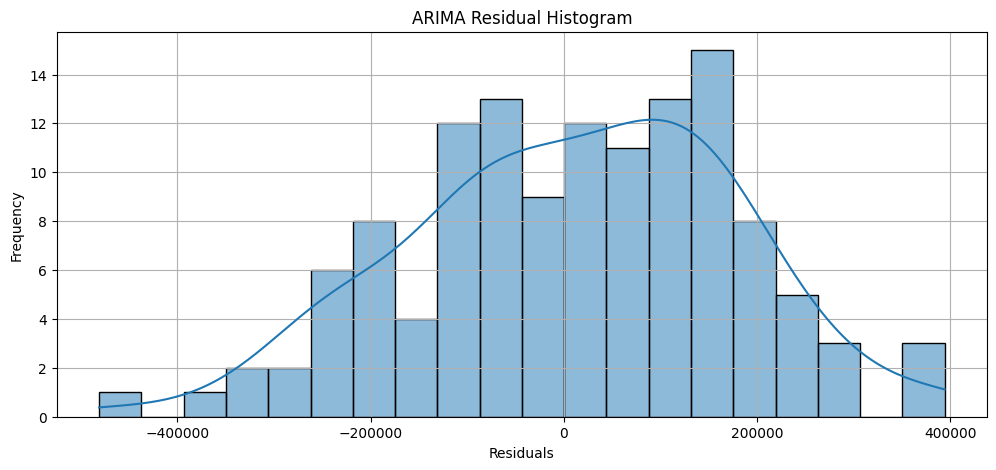

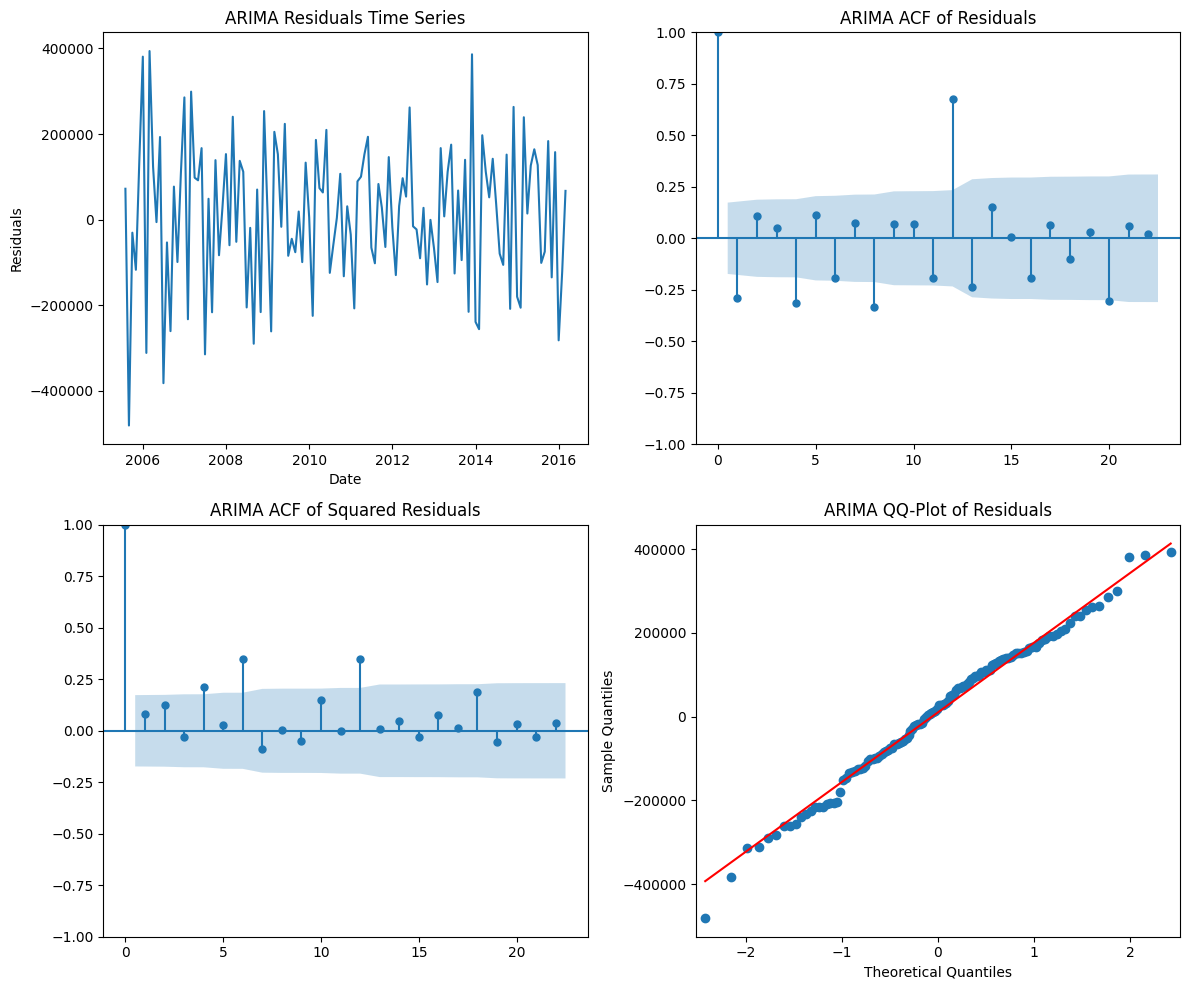

In [115]:
import statsmodels.api as sm

arima_resid = arima_results.resid
arima_resid = arima_resid[1:] # there was an error value in the first column


plt.figure(figsize=(12, 5))
sns.histplot(arima_resid, bins=20, kde=True)
plt.title("ARIMA Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()

plt.show()

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Time series plot of the residuals
axes[0, 0].plot(arima_resid)
axes[0, 0].set_title("ARIMA Residuals Time Series")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Residuals")

# 2. ACF plot of the residuals
plot_acf(arima_resid, ax=axes[0, 1])
axes[0, 1].set_title("ARIMA ACF of Residuals")

# 3. ACF plot of the squared residuals
plot_acf(arima_resid**2, ax=axes[1, 0])
axes[1, 0].set_title("ARIMA ACF of Squared Residuals")

# 4. QQ-plot of the residuals
sm.qqplot(arima_resid, line='s', ax=axes[1, 1])
axes[1, 1].set_title("ARIMA QQ-Plot of Residuals")

plt.tight_layout()
plt.show()

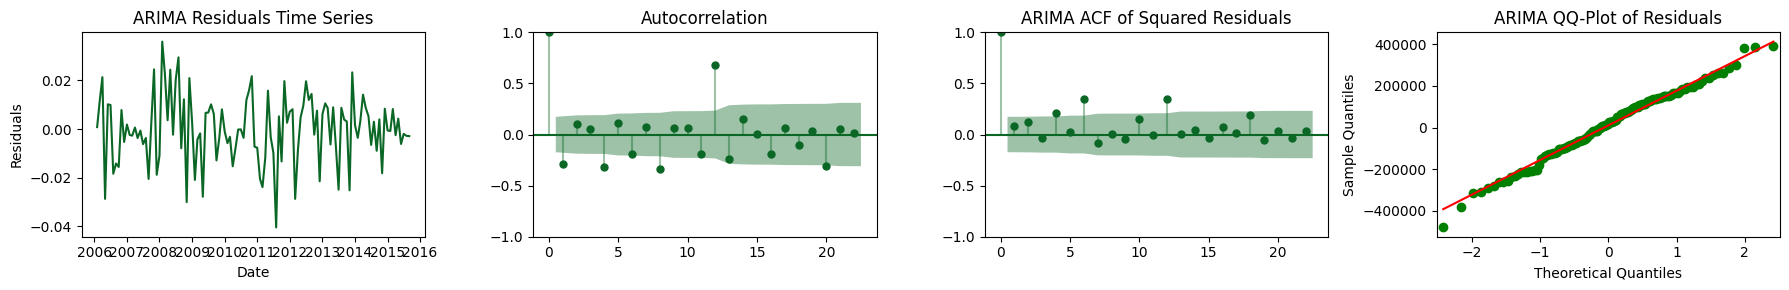

In [116]:
# Create a 1x4 grid of plots
fig, axes = plt.subplots(1, 4, figsize=(18, 3))

# 1. Time series plot of the residuals
axes[0].plot(arma_resid,color=green)
axes[0].set_title("ARIMA Residuals Time Series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residuals")

# 2. ACF plot of the residuals
plot_acf(arima_resid, ax=axes[1],color=green,vlines_kwargs={'colors': green})
for patch in axes[1].collections:
    patch.set_facecolor(green)  # Change CI fill color
    patch.set_alpha(0.4)
axes[2].set_title("ARIMA ACF of Residuals")

# 3. ACF plot of the squared residuals
plot_acf(arima_resid**2, ax=axes[2],color=green,vlines_kwargs={'colors': green})
for patch in axes[2].collections:
    patch.set_facecolor(green)  # Change CI fill color
    patch.set_alpha(0.4)
axes[2].set_title("ARIMA ACF of Squared Residuals")

# 4. QQ-plot of the residuals
sm.qqplot(arima_resid, line='s', ax=axes[3])
for line in axes[3].get_lines():
    line.set_markerfacecolor('green')  # Change marker face color
    line.set_markeredgecolor('green')
axes[3].set_title("ARIMA QQ-Plot of Residuals")

plt.tight_layout()
plt.show()

#### 4.1.3 Forecasting

##### 4.1.3.1 In-Sample Forecasting

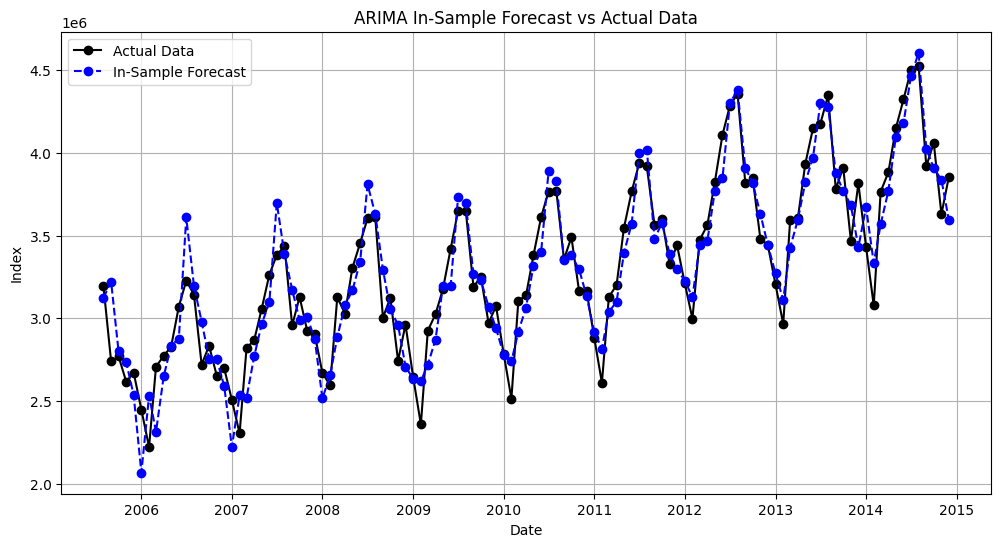

In [117]:
import matplotlib.pyplot as plt

# Split data: use data before 2018 for fitting; for plotting, only 2017 and 2018 are shown.
train1 = flights[flights.index.year < 2015]
test1 = flights[flights.index.year == 2015]
train1_plot = flights[flights.index.year == 2014]

# Align in_sample_forecast with train index
in_sample_forecast1 = arima_results.fittedvalues.loc[train1.index]

# Plot actual vs. in-sample forecast
plt.figure(figsize=(12, 6))
plt.plot(train1.index[1:], train1['Passenger Count'].iloc[1:], label="Actual Data", marker='o', linestyle="-", color="black")
plt.plot(train1.index[1:], in_sample_forecast1.iloc[1:], label="In-Sample Forecast", marker='o', linestyle="--", color="blue")

plt.xlabel("Date")
plt.ylabel("Index")
plt.title("ARIMA In-Sample Forecast vs Actual Data")
plt.legend()
plt.grid()
plt.show()

##### 4.1.3.2 Out-of-Sample Forecasting

In [118]:
# Ensure date index is in datetime format and has monthly frequency
test1.index = pd.to_datetime(test1.index)
train1.index = pd.to_datetime(train1.index)
test1= test1.asfreq('MS')
train1 = train1.asfreq('MS')


# Fit ARIMA model
model = ARIMA(train1['Passenger Count'], order=optimal_pdq_ARIMA)
current_results = model.fit()

# Initialize forecast storage
one_step_forecasts1 = pd.Series(index=test1.index, dtype=float)
one_step_ci_lower1 = pd.Series(index=test1.index, dtype=float)
one_step_ci_upper1 = pd.Series(index=test1.index, dtype=float)

# Rolling one-step ahead forecasts
for date in test1.index:
    forecast_obj = current_results.get_forecast(steps=1)
    forecast_value = forecast_obj.predicted_mean.iloc[0]
    ci = forecast_obj.conf_int().iloc[0]

    one_step_forecasts1.loc[date] = forecast_value
    one_step_ci_lower1.loc[date] = ci[0]
    one_step_ci_upper1.loc[date] = ci[1]

    row_to_append = pd.DataFrame({'Passenger Count': [test1.loc[date, 'Passenger Count']]}, 
                                 index=[date])
    current_results = current_results.append(row_to_append, refit=False)

# 12-month forecast from the end of 2017
forecast_res1 = current_results.get_forecast(steps=12)
forecast_mean1 = forecast_res1.predicted_mean
forecast_ci1 = forecast_res1.conf_int()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/3467693810.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  one_step_ci_lower1.loc[date] = ci[0]
/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/3467693810.py:25: FutureWarning: Series.__getite

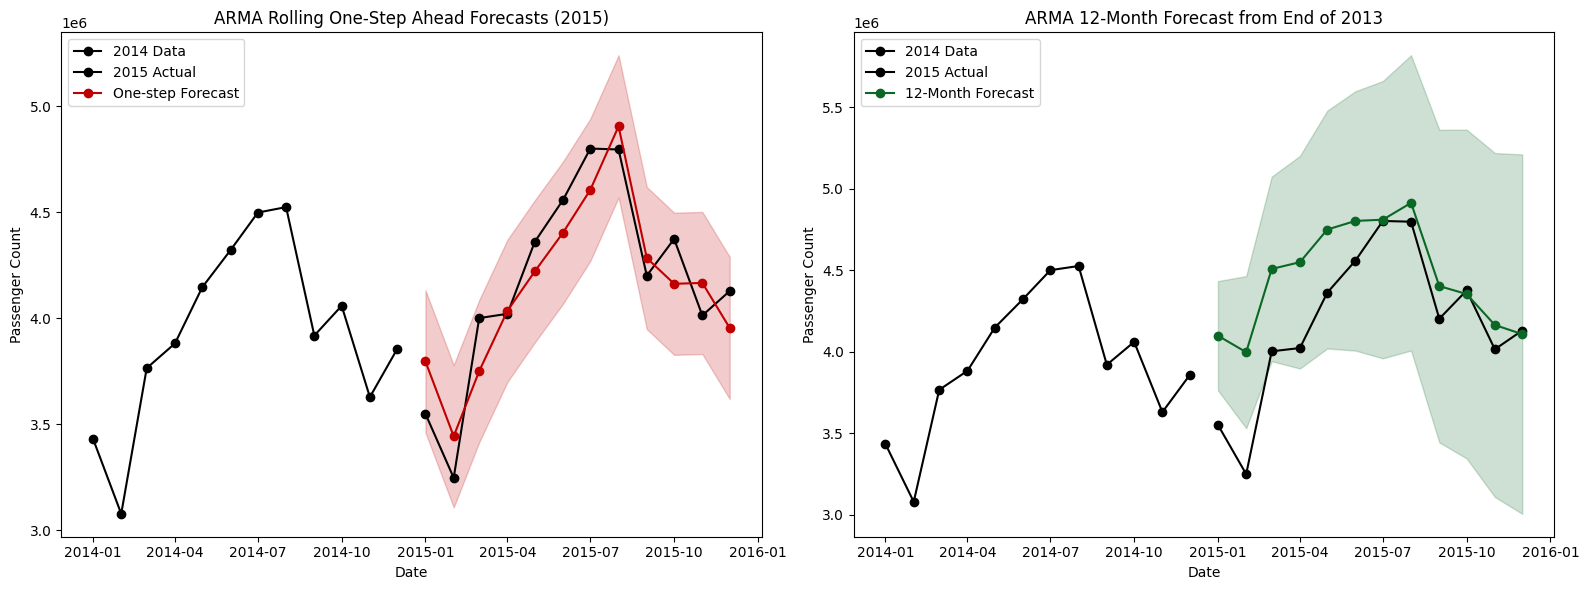

In [119]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Rolling one-step ahead forecasts
axes[0].plot(train1.index[-12:], train1['Passenger Count'].iloc[-12:], label='2014 Data', marker='o', color='black')
axes[0].plot(test1.index, test1['Passenger Count'], label='2015 Actual', color='black', marker='o')
axes[0].plot(one_step_forecasts1.index, one_step_forecasts1, label='One-step Forecast', color=red, marker='o')
axes[0].fill_between(one_step_forecasts1.index, one_step_ci_lower1, one_step_ci_upper1, color=red, alpha=0.2)
axes[0].set_title("ARMA Rolling One-Step Ahead Forecasts (2015)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Passenger Count")
axes[0].legend()

# Correct the forecast index to start at the correct time (January 2014)
forecast_index1 = pd.date_range(start=train1.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Assign the corrected index to forecast values
forecast_mean1.index = forecast_index1
forecast_ci1.index = forecast_index1

# Right plot: 12-month ahead forecast from the end of 2013
axes[1].plot(train1.index[-12:], train1['Passenger Count'].iloc[-12:], label='2014 Data', marker='o',color='black')
axes[1].plot(test1.index, test1['Passenger Count'], label='2015 Actual', color='black', marker='o')

# Ensure forecast_mean and forecast_ci are properly indexed before plotting
axes[1].plot(forecast_mean1.index, forecast_mean1, label='12-Month Forecast', color=green, marker='o')
axes[1].fill_between(forecast_ci1.index, forecast_ci1.iloc[:, 0], forecast_ci1.iloc[:, 1], color=green, alpha=0.2)

axes[1].set_title("ARMA 12-Month Forecast from End of 2013")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Passenger Count")
axes[1].legend()

plt.tight_layout()
plt.show()

##### 4.1.3.3 Forecasting Evaluation

In [120]:
from sklearn.metrics import mean_absolute_error

# Ensure both series have the same index
common_index1_one_step = test1.index.intersection(one_step_forecasts1.index)
common_index1_forecast = test1.index.intersection(forecast_mean1.index)

# Align test data with forecasts
test1_one_step_aligned = test1.loc[common_index1_one_step, 'Passenger Count']
one_step_forecasts_aligned1 = one_step_forecasts1.loc[common_index1_one_step]

test1_forecast_aligned = test1.loc[common_index1_forecast, 'Passenger Count']
forecast_mean_aligned1 = forecast_mean1.loc[common_index1_forecast]

# Compute MAE for both forecasts
mae_one_step1 = mean_absolute_error(test1_one_step_aligned, one_step_forecasts_aligned1)
mae_forecast1 = mean_absolute_error(test1_forecast_aligned, forecast_mean_aligned1)

print(f"ARIMA One-Step Ahead Forecast MAE: {mae_one_step1:.2f}")
print(f"ARIMA 12-Month Forecast MAE: {mae_forecast1:.2f}")

ARIMA One-Step Ahead Forecast MAE: 160621.28
ARIMA 12-Month Forecast MAE: 289489.40


### 4.2 Seasonal ARIMA (SARIMA)

#### 4.2.1 AIC Optimisation

In [121]:
import itertools
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.asfreq('MS')  

# Reduce search space
p = q = range(0, 3)  
d = [1]
P = Q = range(0, 3)  
D = [1]
m = [12]

# Store results
results_list = []

# Grid search with debugging
for param in itertools.product(p, d, q, P, D, Q, m):
    try:
        model = SARIMAX(flights["Passenger Count"].dropna(),
                        order=param[:3],
                        seasonal_order=param[3:],
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        results_list.append([param, model_fit.aic])
    except Exception as e:
        print(f"Error for parameters {param}: {e}")

# Convert results to a DataFrame
results_df1 = pd.DataFrame(results_list, columns=["(p,d,q,P,D,Q,m)", "AIC"]).sort_values(by="AIC")

results_df1

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,"(p,d,q,P,D,Q,m)",AIC
74,"(2, 1, 2, 0, 1, 2, 12)",2269.928323
77,"(2, 1, 2, 1, 1, 2, 12)",2272.102008
80,"(2, 1, 2, 2, 1, 2, 12)",2272.188759
20,"(0, 1, 2, 0, 1, 2, 12)",2274.236893
47,"(1, 1, 2, 0, 1, 2, 12)",2275.876379
...,...,...
36,"(1, 1, 1, 0, 1, 0, 12)",2926.524595
54,"(2, 1, 0, 0, 1, 0, 12)",2926.668688
63,"(2, 1, 1, 0, 1, 0, 12)",2927.910530
27,"(1, 1, 0, 0, 1, 0, 12)",2952.688934


#### 4.2.2 Modelling

##### 4.2.2.1 Model Fitting

In [122]:
optimal_pdqPDQm = (1,1,0,1,1,0,12) #results_df1['(p,d,q,P,D,Q,m)'].iloc[0]
optimal_pdq = optimal_pdqPDQm[:3]
optimal_PDQm = optimal_pdqPDQm[3:]


# Fit SARIMA model
sarima_model = SARIMAX(flights["Passenger Count"], order=optimal_pdq, seasonal_order=optimal_PDQm, enforce_stationarity=True, enforce_invertibility=False)
sarima_results = sarima_model.fit()

##### 4.2.2.2 Residual Plotting

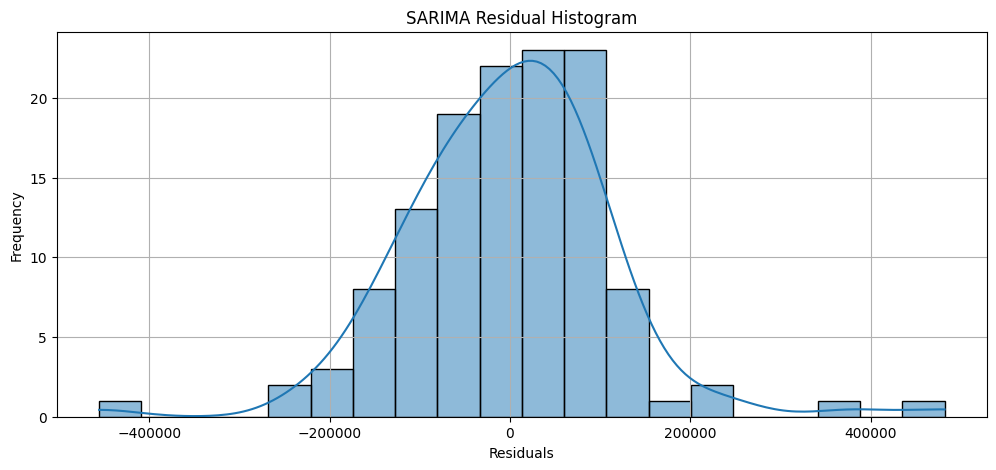

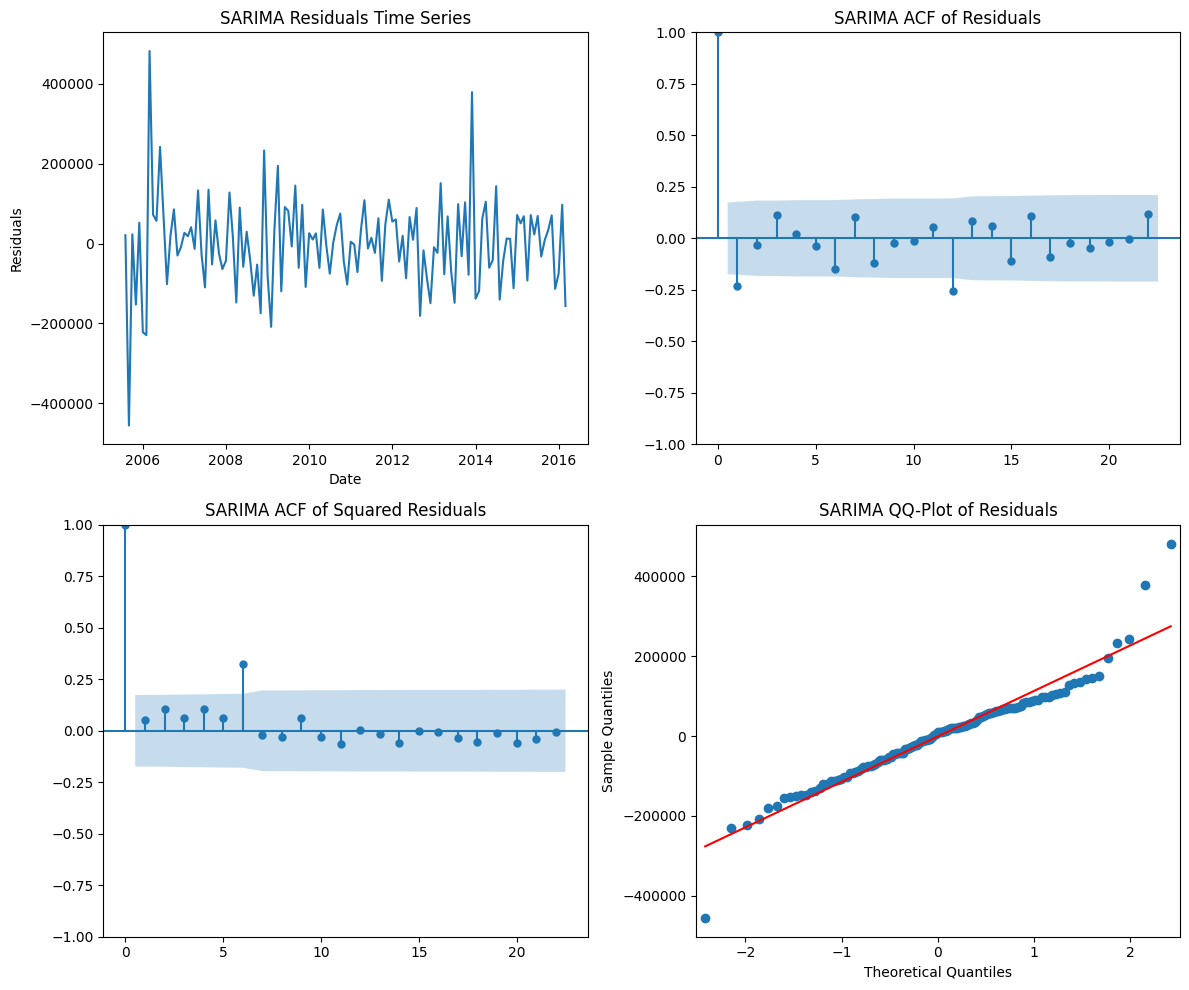

In [123]:
sarima_resid = sarima_results.resid
n = [0,12]
sarima_resid = sarima_resid.drop(sarima_resid.index[n])# there were extreme outliers in the 1st and 13th period

plt.figure(figsize=(12, 5))
sns.histplot(sarima_resid, bins=20, kde=True)
plt.title("SARIMA Residual Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid()

plt.show()

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Time series plot of the residuals
axes[0, 0].plot(sarima_resid)
axes[0, 0].set_title("SARIMA Residuals Time Series")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Residuals")

# 2. ACF plot of the residuals
plot_acf(sarima_resid, ax=axes[0, 1])
axes[0, 1].set_title("SARIMA ACF of Residuals")

# 3. ACF plot of the squared residuals
plot_acf(sarima_resid**2, ax=axes[1, 0])
axes[1, 0].set_title("SARIMA ACF of Squared Residuals")

# 4. QQ-plot of the residuals
sm.qqplot(sarima_resid, line='s', ax=axes[1, 1])
axes[1, 1].set_title("SARIMA QQ-Plot of Residuals")

plt.tight_layout()
plt.show()

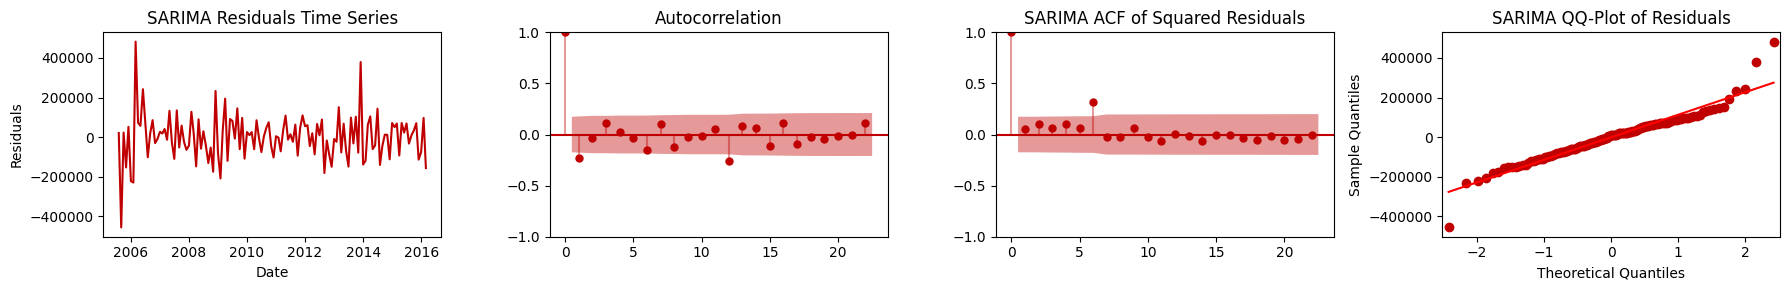

In [124]:
# Create a 1x4 grid of plots
fig, axes = plt.subplots(1, 4, figsize=(18, 3))

# 1. Time series plot of the residuals
axes[0].plot(sarima_resid,color=red)
axes[0].set_title("SARIMA Residuals Time Series")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residuals")

# 2. ACF plot of the residuals
plot_acf(sarima_resid, ax=axes[1],color=red,vlines_kwargs={'colors': red})
for patch in axes[1].collections:
    patch.set_facecolor(red)  # Change CI fill color
    patch.set_alpha(0.4)
axes[2].set_title("SARIMA ACF of Residuals")

# 3. ACF plot of the squared residuals
plot_acf(sarima_resid**2, ax=axes[2],color=red,vlines_kwargs={'colors': red})
for patch in axes[2].collections:
    patch.set_facecolor(red)  # Change CI fill color
    patch.set_alpha(0.4)
axes[2].set_title("SARIMA ACF of Squared Residuals")

# 4. QQ-plot of the residuals
sm.qqplot(sarima_resid, line='s', ax=axes[3])
for line in axes[3].get_lines():
    line.set_markerfacecolor(red)  # Change marker face color
    line.set_markeredgecolor(red)
axes[3].set_title("SARIMA QQ-Plot of Residuals")

plt.tight_layout()
plt.show()

#### 4.2.3 Forecasting

##### 4.2.3.1 In-Sample Forecasting

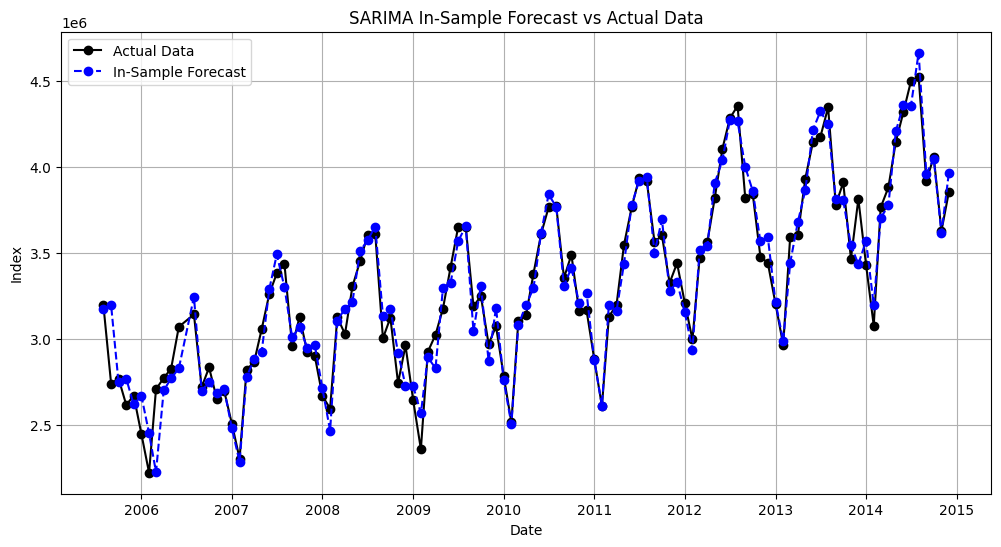

In [125]:
# Split data: use data before 2018 for fitting; for plotting, only 2017 and 2018 are shown.
train2 = flights[flights.index.year < 2015]
test2 = flights[flights.index.year == 2015]
train2_plot = flights[flights.index.year == 2014]

# Align in_sample_forecast with train index
in_sample_forecast2 = sarima_results.fittedvalues.loc[train2.index]

# Plot actual vs. in-sample forecast
plt.figure(figsize=(12, 6))
plt.plot(train2.index.drop(train2.index[n]), train2['Passenger Count'].drop(train2.index[n]), label="Actual Data", marker='o', linestyle="-", color="black")
plt.plot(train2.index.drop(train2.index[n]), in_sample_forecast2.drop(in_sample_forecast2.index[n]), label="In-Sample Forecast", marker='o', linestyle="--", color="blue")

plt.xlabel("Date")
plt.ylabel("Index")
plt.title("SARIMA In-Sample Forecast vs Actual Data")
plt.legend()
plt.grid()
plt.show()

##### 4.2.3.2 Out-of-Sample Forecasting

In [126]:
# Initialize forecast storage
one_step_forecasts2 = pd.Series(index=test2.index, dtype=float)
one_step_ci_lower2 = pd.Series(index=test2.index, dtype=float)
one_step_ci_upper2 = pd.Series(index=test2.index, dtype=float)


# Rolling one-step ahead forecasts
for date in test2.index:
    forecast_obj = sarima_results.get_forecast(steps=1)
    forecast_value = forecast_obj.predicted_mean.iloc[0]
    ci = forecast_obj.conf_int().iloc[0]

    one_step_forecasts2.loc[date] = forecast_value
    one_step_ci_lower2.loc[date] = ci[0]
    one_step_ci_upper2.loc[date] = ci[1]

    # Retrieve last index from the model
    last_index = sarima_results.model.data.row_labels[-1]  # Corrected line

    # Ensure the new data point extends the time series correctly
    new_index = last_index + pd.DateOffset(months=1)  # Move one month ahead
    row_to_append = pd.DataFrame({'Passenger Count': [test2.loc[date, 'Passenger Count']]}, index=[new_index])

    # Append the new observation to update the model state
    sarima_results = sarima_results.append(row_to_append, refit=False)

# 12-month forecast from the end of the last training data point
forecast_res_sarima = sarima_results.get_forecast(steps=12)
forecast_mean_sarima = forecast_res_sarima.predicted_mean
forecast_ci_sarima = forecast_res_sarima.conf_int()


/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/1631728220.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  one_step_ci_lower2.loc[date] = ci[0]
/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/1631728220.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  one_step_ci_upper2.loc[date] = ci[1]
/var/folders/8m/_6ttb91j0dl6ptlnvls6lf040000gn/T/ipykernel_30378/1631728220.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

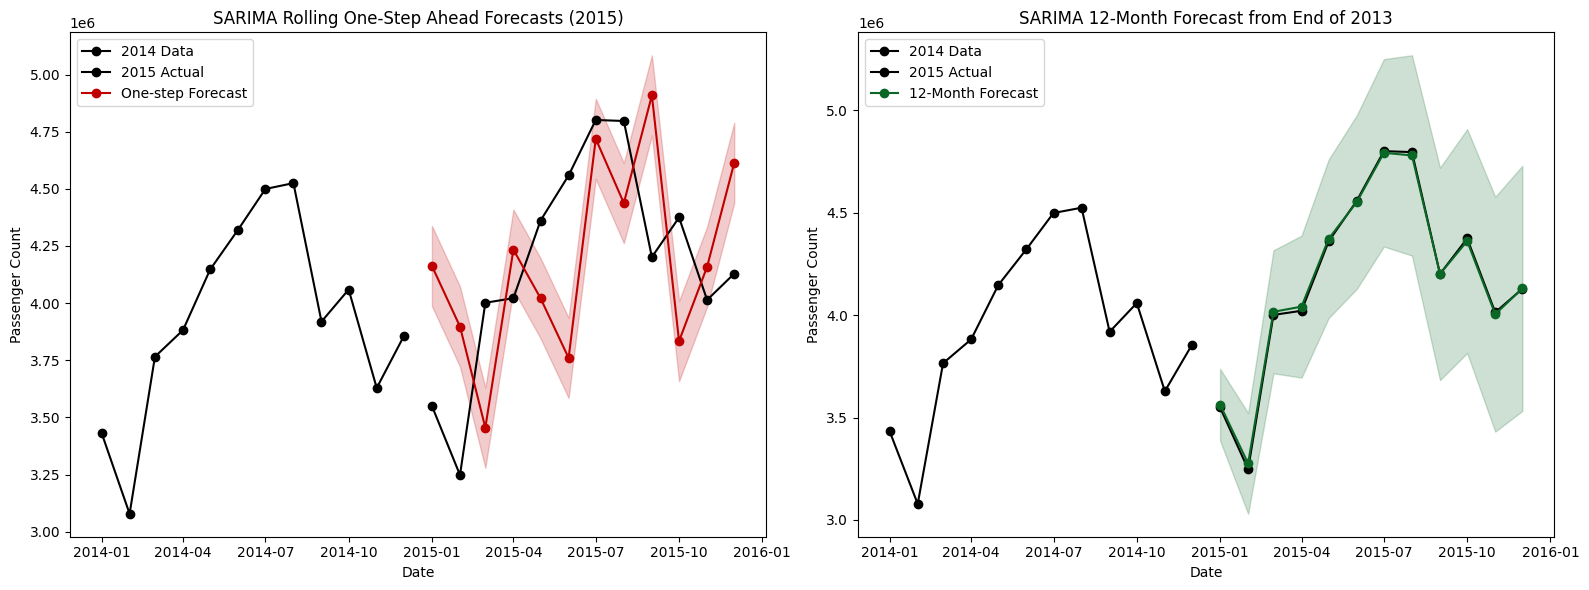

In [127]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Rolling one-step ahead forecasts
axes[0].plot(train2.index[-12:], train2['Passenger Count'].iloc[-12:], label='2014 Data', marker='o', color='black')
axes[0].plot(test2.index, test2['Passenger Count'], label='2015 Actual', color='black', marker='o')
axes[0].plot(one_step_forecasts2.index, one_step_forecasts2, label='One-step Forecast', color=red, marker='o')
axes[0].fill_between(one_step_forecasts2.index, one_step_ci_lower2, one_step_ci_upper2, color=red, alpha=0.2)
axes[0].set_title("SARIMA Rolling One-Step Ahead Forecasts (2015)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Passenger Count")
axes[0].legend()

# Correct the forecast index to start at the correct time
forecast_index_sarima = pd.date_range(start=train2.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Assign the corrected index to forecast values
forecast_mean_sarima.index = forecast_index_sarima
forecast_ci_sarima.index = forecast_index_sarima

# Right plot: 12-month ahead forecast from the end of 2013
axes[1].plot(train2.index[-12:], train2['Passenger Count'].iloc[-12:], label='2014 Data', marker='o', color='black')
axes[1].plot(test2.index, test2['Passenger Count'], label='2015 Actual', color='black', marker='o')
axes[1].plot(forecast_mean_sarima.index, forecast_mean_sarima, label='12-Month Forecast', color=green, marker='o')
axes[1].fill_between(forecast_ci_sarima.index, forecast_ci_sarima.iloc[:, 0], forecast_ci_sarima.iloc[:, 1], color=green, alpha=0.2)

axes[1].set_title("SARIMA 12-Month Forecast from End of 2013")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Passenger Count")
axes[1].legend()
plt.tight_layout()
plt.show()

##### 4.2.3.3 Forecast Evaluation

In [128]:
# Ensure both series have the same index
common_index2_one_step = test2.index.intersection(one_step_forecasts2.index)
common_index2_forecast = test2.index.intersection(forecast_mean_sarima.index)

# Align test data with forecasts
test2_one_step_aligned = test2.loc[common_index2_one_step, 'Passenger Count']
one_step_forecasts_aligned2 = one_step_forecasts2.loc[common_index2_one_step]

test2_forecast_aligned = test2.loc[common_index2_forecast, 'Passenger Count']
forecast_mean_aligned2 = forecast_mean_sarima.loc[common_index2_forecast]

# Compute MAE for both forecasts
mae_one_step2 = mean_absolute_error(test2_one_step_aligned, one_step_forecasts_aligned2)
mae_forecast2 = mean_absolute_error(test2_forecast_aligned, forecast_mean_aligned2)

print(f"SARIMA One-Step Ahead Forecast MAE: {mae_one_step2:.2f}")
print(f"SARIMA 12-Month Forecast MAE: {mae_forecast2:.2f}")

SARIMA One-Step Ahead Forecast MAE: 456551.04
SARIMA 12-Month Forecast MAE: 11962.94


# 5. Conclusions 

In [129]:
print(f"ARMA One-Step Ahead Forecast MAE: {mae_one_step0:.2f}")
print(f"ARMA 12-Month Forecast MAE: {mae_forecast0:.2f}\n")

print(f"ARIMA One-Step Ahead Forecast MAE: {mae_one_step1:.2f}")
print(f"ARIMA 12-Month Forecast MAE: {mae_forecast1:.2f}\n")

print(f"SARIMA One-Step Ahead Forecast MAE: {mae_one_step2:.2f}")
print(f"SARIMA 12-Month Forecast MAE: {mae_forecast2:.2f}")

conclusionDF = {}

ARMA One-Step Ahead Forecast MAE: 279232.98
ARMA 12-Month Forecast MAE: 863771.53

ARIMA One-Step Ahead Forecast MAE: 160621.28
ARIMA 12-Month Forecast MAE: 289489.40

SARIMA One-Step Ahead Forecast MAE: 456551.04
SARIMA 12-Month Forecast MAE: 11962.94


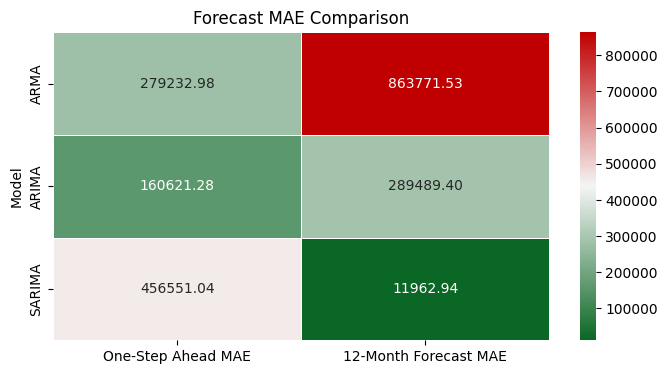

In [130]:
import pandas as pd

# Sample MAE values (Replace these with your actual values)
data = {
    "Model": ["ARMA", "ARIMA", "SARIMA"],
    "One-Step Ahead MAE": [mae_one_step0, mae_one_step1, mae_one_step2],
    "12-Month Forecast MAE": [mae_forecast0, mae_forecast1, mae_forecast2]
}

# Create DataFrame
mae_df = pd.DataFrame(data)

mae_df.set_index("Model", inplace=True)

custom_red = red   # Example: More orange-toned red
custom_green = green # Example: More neon green

# Create a custom colormap
custom_cmap = LinearSegmentedColormap.from_list("CustomRdYlGn", [green, "#F5F5F5", red])

# Create the heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(mae_df, annot=True, fmt=".2f", cmap=custom_cmap, linewidths=0.5)

# Set title
plt.title("Forecast MAE Comparison")

# Show the plot
plt.show()